In [1]:
# pulling in all the data we built across the first two notebooks
# three csvs: nav data, fund metrics, sip results

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

master_df     = pd.read_csv('../data/all_funds_nav.csv')
comparison_df = pd.read_csv('../data/fund_comparison.csv')
sip_df        = pd.read_csv('../data/sip_comparison.csv')

master_df['date'] = pd.to_datetime(master_df['date'])

print(f"nav data    : {len(master_df):,} rows | {master_df['fund_name'].nunique()} funds")
print(f"metrics     : {len(comparison_df)} funds | columns: {list(comparison_df.columns)}")
print(f"sip results : {len(sip_df)} funds")
print()
print("funds in comparison_df:")
print(comparison_df[['Fund Name', 'Category', 'CAGR 5Y (%)', 'Sharpe Ratio']].to_string(index=False))

nav data    : 96,325 rows | 33 funds
metrics     : 33 funds | columns: ['Fund Name', 'Category', 'CAGR 5Y (%)', 'CAGR 1Y (%)', 'Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
sip results : 33 funds

funds in comparison_df:
                                Fund Name   Category  CAGR 5Y (%)  Sharpe Ratio
                     Quant Small Cap Fund  Small Cap        35.54          1.29
              Nippon India Small Cap Fund  Small Cap        27.26          1.06
             Canara Robeco Small Cap Fund  Small Cap        26.21          1.04
              Parag Parikh Flexi Cap Fund  Large Cap        20.39          0.98
                   Edelweiss Mid Cap Fund    Mid Cap        25.47          0.98
                       DSP Small Cap Fund  Small Cap        24.13          0.96
                       Quant Mid Cap Fund    Mid Cap        25.70          0.96
         Nippon India Growth Mid Cap Fund    Mid Cap        24.20          0.95
                Invesco India Midcap Fund    Mid Ca

ACTIVE vs PASSIVE — 5 year comparison
---------------------------------------------
active funds  (25 funds)
  avg cagr    : 21.12%
  avg sharpe  : 0.83

passive funds (8 funds)
  avg cagr    : 14.88%
  avg sharpe  : 0.52

active funds beat passive by 6.24% on cagr
active funds beat passive by 0.31 on sharpe ratio

best index fund cagr    : 22.43%
active funds beating it : 10 out of 25

                       Fund Name  Category  CAGR 5Y (%)  Sharpe Ratio
            Quant Small Cap Fund Small Cap        35.54          1.29
     Nippon India Small Cap Fund Small Cap        27.26          1.06
    Canara Robeco Small Cap Fund Small Cap        26.21          1.04
          Edelweiss Mid Cap Fund   Mid Cap        25.47          0.98
              DSP Small Cap Fund Small Cap        24.13          0.96
              Quant Mid Cap Fund   Mid Cap        25.70          0.96
Nippon India Growth Mid Cap Fund   Mid Cap        24.20          0.95
       Invesco India Midcap Fund   Mid Cap        

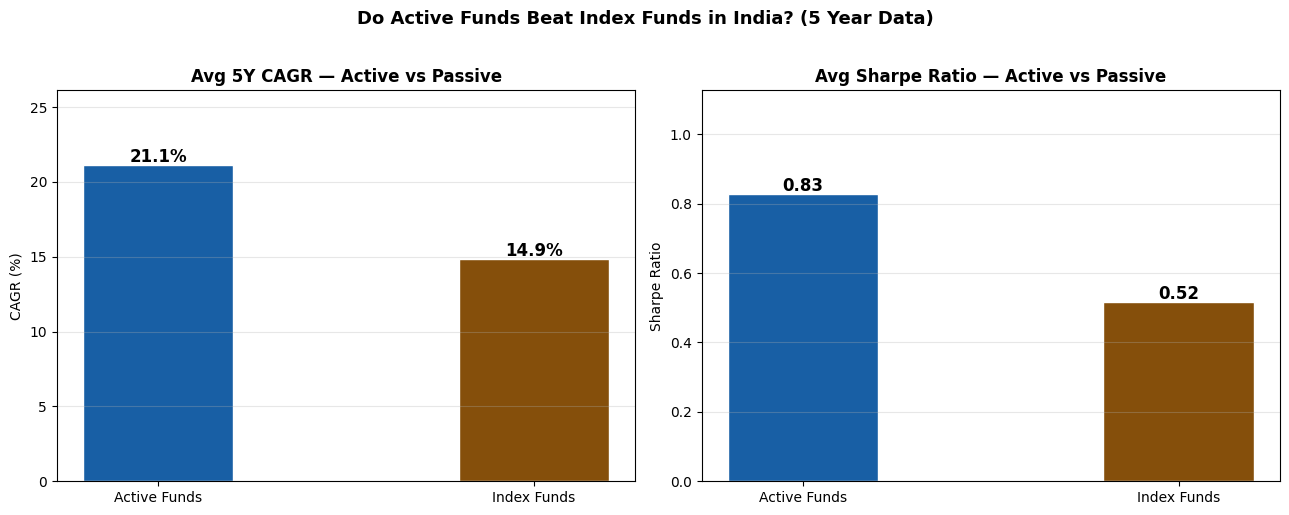

saved to output/active_vs_passive.png


In [2]:
# big question: do actively managed funds beat index funds in india?
# globally the answer is usually no. lets see what our data says.

active_df  = comparison_df[comparison_df['Category'] != 'Index Fund'].copy()
passive_df = comparison_df[comparison_df['Category'] == 'Index Fund'].copy()

active_avg_cagr    = active_df['CAGR 5Y (%)'].mean()
passive_avg_cagr   = passive_df['CAGR 5Y (%)'].mean()
active_avg_sharpe  = active_df['Sharpe Ratio'].mean()
passive_avg_sharpe = passive_df['Sharpe Ratio'].mean()

print("ACTIVE vs PASSIVE — 5 year comparison")
print("-" * 45)
print(f"active funds  ({len(active_df)} funds)")
print(f"  avg cagr    : {active_avg_cagr:.2f}%")
print(f"  avg sharpe  : {active_avg_sharpe:.2f}")
print()
print(f"passive funds ({len(passive_df)} funds)")
print(f"  avg cagr    : {passive_avg_cagr:.2f}%")
print(f"  avg sharpe  : {passive_avg_sharpe:.2f}")
print()
print(f"active funds beat passive by {active_avg_cagr - passive_avg_cagr:.2f}% on cagr")
print(f"active funds beat passive by {active_avg_sharpe - passive_avg_sharpe:.2f} on sharpe ratio")
print()

# how many active funds individually beat the best index fund?
best_passive_cagr = passive_df['CAGR 5Y (%)'].max()
active_beating    = active_df[active_df['CAGR 5Y (%)'] > best_passive_cagr]

print(f"best index fund cagr    : {best_passive_cagr:.2f}%")
print(f"active funds beating it : {len(active_beating)} out of {len(active_df)}")
print()
print(active_beating[['Fund Name', 'Category', 'CAGR 5Y (%)', 'Sharpe Ratio']].to_string(index=False))

# now the chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = ['Active Funds', 'Index Funds']
cagr_vals  = [active_avg_cagr, passive_avg_cagr]
sharpe_vals = [active_avg_sharpe, passive_avg_sharpe]
bar_colors  = ['#185FA5', '#854F0B']

b1 = axes[0].bar(categories, cagr_vals, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(b1, cagr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Avg 5Y CAGR — Active vs Passive', fontweight='bold')
axes[0].set_ylabel('CAGR (%)')
axes[0].set_ylim(0, max(cagr_vals) + 5)
axes[0].grid(axis='y', alpha=0.3)

b2 = axes[1].bar(categories, sharpe_vals, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(b2, sharpe_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Sharpe Ratio — Active vs Passive', fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_ylim(0, max(sharpe_vals) + 0.3)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Do Active Funds Beat Index Funds in India? (5 Year Data)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/active_vs_passive.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to output/active_vs_passive.png")

analysing rolling returns for:
  - Quant Small Cap Fund
  - Nippon India Small Cap Fund
  - Canara Robeco Small Cap Fund
  - Parag Parikh Flexi Cap Fund
  - Edelweiss Mid Cap Fund

Quant Small Cap Fund                      
  avg 1yr return : 47.6%
  best window    : 224.4%
  worst window   : -11.0%
  positive %     : 84% of all 1yr windows were profitable

Nippon India Small Cap Fund               
  avg 1yr return : 37.8%
  best window    : 136.3%
  worst window   : -9.9%
  positive %     : 90% of all 1yr windows were profitable

Canara Robeco Small Cap Fund              
  avg 1yr return : 34.3%
  best window    : 125.0%
  worst window   : -9.5%
  positive %     : 89% of all 1yr windows were profitable

Parag Parikh Flexi Cap Fund               
  avg 1yr return : 26.2%
  best window    : 98.7%
  worst window   : -7.3%
  positive %     : 93% of all 1yr windows were profitable

Edelweiss Mid Cap Fund                    
  avg 1yr return : 33.6%
  best window    : 112.3%
  worst windo

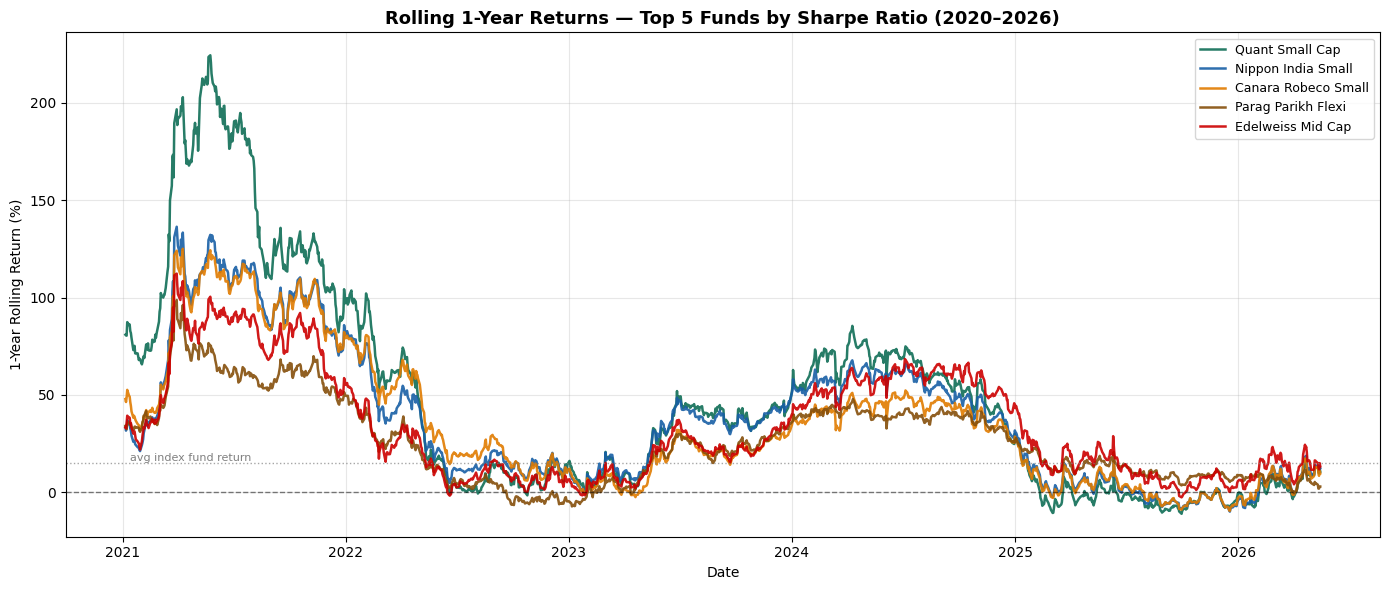

saved to output/rolling_returns.png


In [4]:
# rolling returns analysis — checks if a fund performs well across
# different 1-year windows, not just one fixed period
# a fund that scores well here is genuinely consistent, not just lucky

# we take the top 5 funds by sharpe ratio for this
top5 = comparison_df.nlargest(5, 'Sharpe Ratio')['Fund Name'].tolist()
print("analysing rolling returns for:")
for f in top5:
    print(f"  - {f}")
print()

# for each fund, calculate 1-year rolling cagr at every point in time
# window = 252 trading days ~ 1 year
rolling_results = {}

for fund_name in top5:
    fund_data = master_df[master_df['fund_name'] == fund_name].copy()
    fund_data = fund_data.sort_values('date').reset_index(drop=True)

    # only look at 2020 onwards to keep it comparable
    fund_data = fund_data[fund_data['date'] >= '2020-01-01'].copy()

    if len(fund_data) < 252:
        continue

    # rolling 1yr return: compare nav today vs nav 252 days ago
    fund_data['nav_1yr_ago'] = fund_data['nav'].shift(252)
    fund_data['rolling_1yr_return'] = (
        (fund_data['nav'] / fund_data['nav_1yr_ago']) - 1
    ) * 100

    fund_data = fund_data.dropna(subset=['rolling_1yr_return'])
    rolling_results[fund_name] = fund_data[['date', 'rolling_1yr_return']]

    avg = fund_data['rolling_1yr_return'].mean()
    worst = fund_data['rolling_1yr_return'].min()
    best  = fund_data['rolling_1yr_return'].max()
    # what % of the time did this fund give positive 1yr returns
    positive_pct = (fund_data['rolling_1yr_return'] > 0).mean() * 100

    print(f"{fund_name[:42]:<42}")
    print(f"  avg 1yr return : {avg:.1f}%")
    print(f"  best window    : {best:.1f}%")
    print(f"  worst window   : {worst:.1f}%")
    print(f"  positive %     : {positive_pct:.0f}% of all 1yr windows were profitable")
    print()

# chart — rolling 1yr returns over time for all 5 funds
colors = ['#0F6E56', '#185FA5', '#E07B00', '#854F0B', '#CC0000']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (fund_name, data) in enumerate(rolling_results.items()):
    short = ' '.join(fund_name.split()[:3])
    ax.plot(data['date'], data['rolling_1yr_return'],
            label=short, color=colors[i], linewidth=1.8, alpha=0.9)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(comparison_df[comparison_df['Category'] == 'Index Fund']['CAGR 5Y (%)'].mean(),
           color='grey', linewidth=1, linestyle=':', alpha=0.7)
ax.text(data['date'].iloc[5],
        comparison_df[comparison_df['Category'] == 'Index Fund']['CAGR 5Y (%)'].mean() + 1,
        'avg index fund return', fontsize=8, color='grey')

ax.set_title('Rolling 1-Year Returns — Top 5 Funds by Sharpe Ratio (2020–2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('1-Year Rolling Return (%)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/rolling_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to output/rolling_returns.png")

In [5]:
# final rankings — merge metrics and sip data into one master table
# this gives a complete picture of each fund across all dimensions

# merge comparison_df and sip_df on fund name
final_df = comparison_df.merge(
    sip_df[['Fund Name', 'Current Value', 'Profit', 'Returns (%)']],
    on='Fund Name',
    how='left'
)

# rename sip columns to be clearer
final_df = final_df.rename(columns={
    'Returns (%)' : 'SIP Returns (%)',
    'Current Value': 'SIP Value (₹)',
    'Profit'       : 'SIP Profit (₹)',
})

# create a simple overall score
# equal weight: normalise cagr, sharpe, sip returns — then average them
# normalise means: scale each column so highest = 1, lowest = 0
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

final_df['score'] = (
    normalise(final_df['CAGR 5Y (%)'])    * 0.35 +
    normalise(final_df['Sharpe Ratio'])   * 0.35 +
    normalise(final_df['SIP Returns (%)']) * 0.30
)

final_df['Rank'] = final_df['score'].rank(ascending=False).astype(int)
final_df = final_df.sort_values('Rank')

print("FINAL FUND RANKINGS — ALL 33 FUNDS")
print("-" * 95)

cols_to_show = ['Rank', 'Fund Name', 'Category',
                'CAGR 5Y (%)', 'Sharpe Ratio', 'SIP Returns (%)', 'Max Drawdown (%)']

print(final_df[cols_to_show].to_string(index=False))
print()

# best fund per category based on score
print("winner per category:")
print("-" * 60)
for cat in ['Small Cap', 'Mid Cap', 'Large Cap', 'Index Fund']:
    cat_df  = final_df[final_df['Category'] == cat]
    winner  = cat_df.iloc[0]
    print(f"  {cat:<12} → {winner['Fund Name']}")
    print(f"              cagr: {winner['CAGR 5Y (%)']:.1f}% | sharpe: {winner['Sharpe Ratio']:.2f} | sip: {winner['SIP Returns (%)']:.1f}%")
    print()

# save the final rankings
final_df.to_csv('../data/final_rankings.csv', index=False)
print("saved to data/final_rankings.csv")

FINAL FUND RANKINGS — ALL 33 FUNDS
-----------------------------------------------------------------------------------------------
 Rank                                 Fund Name   Category  CAGR 5Y (%)  Sharpe Ratio  SIP Returns (%)  Max Drawdown (%)
    1                      Quant Small Cap Fund  Small Cap        35.54          1.29           174.97            -38.57
    2               Nippon India Small Cap Fund  Small Cap        27.26          1.06           145.87            -40.30
    3                    Edelweiss Mid Cap Fund    Mid Cap        25.47          0.98           144.23            -36.84
    4              Canara Robeco Small Cap Fund  Small Cap        26.21          1.04           114.68            -36.18
    5          Nippon India Growth Mid Cap Fund    Mid Cap        24.20          0.95           139.53            -35.32
    6                 Invesco India Midcap Fund    Mid Cap        23.94          0.94           137.58            -34.09
    7                 

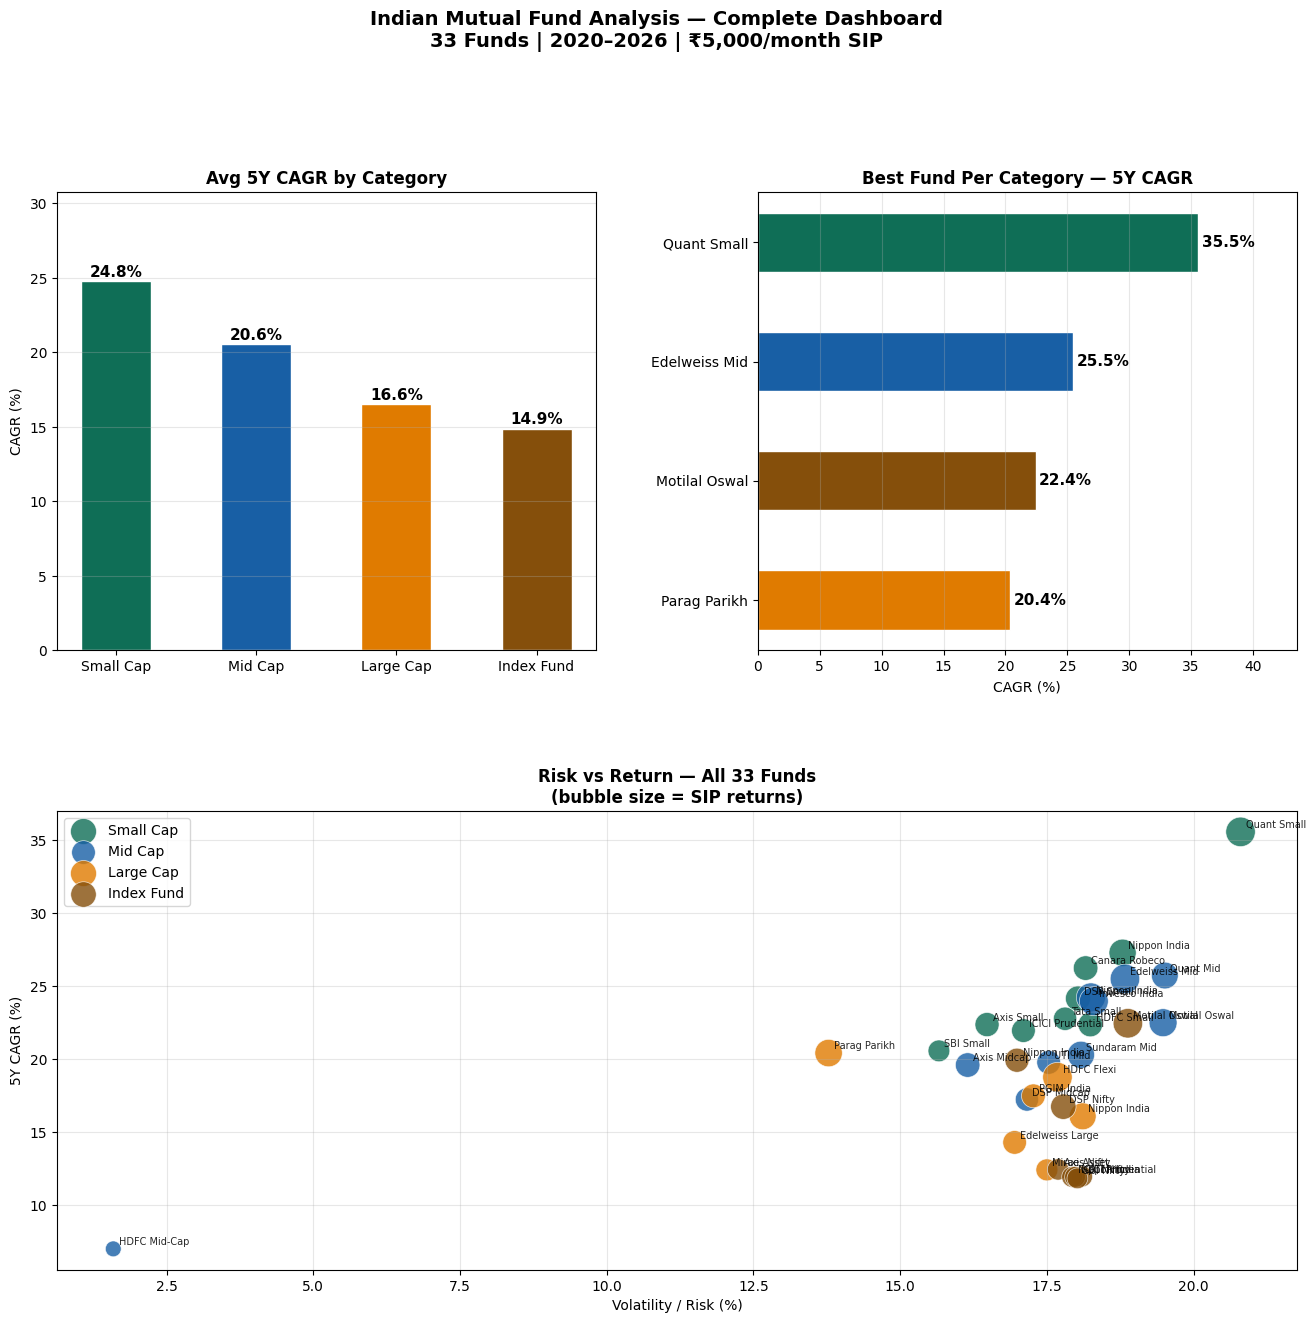

saved to output/final_dashboard.png


In [6]:
# final chart — ties together cagr, sharpe, and sip returns in one visual
# three panels: category comparison, best fund per category, full scatter

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

category_colors = {
    'Small Cap'  : '#0F6E56',
    'Mid Cap'    : '#185FA5',
    'Large Cap'  : '#E07B00',
    'Index Fund' : '#854F0B',
}

# -------------------------------------------------------
# panel 1 (top left) — avg cagr by category
# -------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

cat_avg = final_df.groupby('Category')['CAGR 5Y (%)'].mean().sort_values(ascending=False)
colors1 = [category_colors[c] for c in cat_avg.index]

bars1 = ax1.bar(cat_avg.index, cat_avg.values, color=colors1, width=0.5, edgecolor='white')
for bar, val in zip(bars1, cat_avg.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax1.set_title('Avg 5Y CAGR by Category', fontweight='bold')
ax1.set_ylabel('CAGR (%)')
ax1.set_ylim(0, cat_avg.max() + 6)
ax1.grid(axis='y', alpha=0.3)

# -------------------------------------------------------
# panel 2 (top right) — best fund per category, cagr bars
# -------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

winners = {
    'Small Cap'  : 'Quant Small Cap Fund',
    'Mid Cap'    : 'Edelweiss Mid Cap Fund',
    'Large Cap'  : 'Parag Parikh Flexi Cap Fund',
    'Index Fund' : 'Motilal Oswal Nifty Midcap 150 Index Fund',
}

winner_rows = final_df[final_df['Fund Name'].isin(winners.values())].copy()
winner_rows = winner_rows.sort_values('CAGR 5Y (%)', ascending=False)

short_names = [' '.join(n.split()[:2]) for n in winner_rows['Fund Name']]
colors2     = [category_colors[c] for c in winner_rows['Category']]

bars2 = ax2.barh(short_names, winner_rows['CAGR 5Y (%)'],
                 color=colors2, height=0.5, edgecolor='white')
for bar, val in zip(bars2, winner_rows['CAGR 5Y (%)']):
    ax2.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

ax2.set_title('Best Fund Per Category — 5Y CAGR', fontweight='bold')
ax2.set_xlabel('CAGR (%)')
ax2.set_xlim(0, winner_rows['CAGR 5Y (%)'].max() + 8)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# -------------------------------------------------------
# panel 3 (bottom — full width) — risk vs return scatter
# all 33 funds, coloured by category, sized by sip returns
# -------------------------------------------------------
ax3 = fig.add_subplot(gs[1, :])

for cat, color in category_colors.items():
    cat_data = final_df[final_df['Category'] == cat]
    sizes    = (cat_data['SIP Returns (%)'] / cat_data['SIP Returns (%)'].max()) * 400 + 50

    ax3.scatter(cat_data['Volatility (%)'], cat_data['CAGR 5Y (%)'],
                color=color, s=sizes, label=cat, alpha=0.8, edgecolors='white', linewidth=0.5)

    # label each dot with a short fund name
    for _, row in cat_data.iterrows():
        short = row['Fund Name'].split()[0] + ' ' + row['Fund Name'].split()[1]
        ax3.annotate(short,
                     (row['Volatility (%)'], row['CAGR 5Y (%)']),
                     fontsize=7, xytext=(4, 3),
                     textcoords='offset points', alpha=0.85)

ax3.set_title('Risk vs Return — All 33 Funds\n(bubble size = SIP returns)',
              fontweight='bold')
ax3.set_xlabel('Volatility / Risk (%)')
ax3.set_ylabel('5Y CAGR (%)')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.suptitle('Indian Mutual Fund Analysis — Complete Dashboard\n33 Funds | 2020–2026 | ₹5,000/month SIP',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('../output/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to output/final_dashboard.png")